# Heat Index

In [5]:
!pip install geopandas pygris mapclassify matplotlib fiona
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pygris import counties
import os
import fiona

In [ ]:
import ftplib
import os
import zipfile
import io
import rioxarray
import geopandas as gpd
import pandas as pd
import sys

# SETUP
print(" starting PRISM downloader...")

nova_shape = gpd.read_file("nova_boundaries.geojson").to_crs("EPSG:4326")
bounds = nova_shape.total_bounds
temp_dir = "prism_daily_parts"
os.makedirs(temp_dir, exist_ok=True)

# warm season 2023
start_date = "20230501"
end_date   = "20230930"
target_dates = set(d.strftime("%Y%m%d") for d in pd.date_range(start=start_date, end=end_date))
ftp_host = "prism.oregonstate.edu"

# DOWNLOAD LOOP
try:
    with ftplib.FTP(ftp_host) as ftp:
        ftp.login()
        print(" connected to PRISM FTP.")

        for var in ['tmax', 'tdmean']:
            ftp_path = f"/time_series/us/an/4km/{var}/daily/2023/"
            print(f"\n Processing {var}...")

            try:
                ftp.cwd(ftp_path)
            except:
                print(f" Could not find folder for {var}")
                continue

            file_list = []
            ftp.retrlines('NLST', file_list.append)

            count = 0
            total_files = len(target_dates)

            for filename in file_list:
                if not filename.endswith('.zip'): continue

                # Check if file matches our date range
                date_match = next((d for d in target_dates if d in filename), None)

                if date_match:
                    local_file = os.path.join(temp_dir, f"{var}_{date_match}.nc")

                    # Skip if exists
                    if os.path.exists(local_file):
                        count += 1
                        sys.stdout.write(f"\r progress: {count}/{total_files} days saved.")
                        sys.stdout.flush()
                        continue

                    # Download to RAM
                    r = io.BytesIO()
                    try:
                        ftp.retrbinary(f"RETR {filename}", r.write)
                    except:
                        continue
                    r.seek(0)

                    # unzip, clip, save
                    try:
                        with zipfile.ZipFile(r) as z:
                            # Handle .bil or .tif variation
                            valid_files = [n for n in z.namelist() if n.lower().endswith(('.bil', '.tif'))]
                            if not valid_files: continue

                            data_filename = valid_files[0]
                            z.extract(data_filename, path=temp_dir)
                            raw_path = os.path.join(temp_dir, data_filename)

                            with rioxarray.open_rasterio(raw_path) as da:
                                da_clipped = da.squeeze().rio.clip_box(
                                    minx=bounds[0]-0.1, miny=bounds[1]-0.1,
                                    maxx=bounds[2]+0.1, maxy=bounds[3]+0.1
                                )
                                da_clipped.to_netcdf(local_file)

                            # Clean up raw extraction
                            os.remove(raw_path)
                            base = os.path.splitext(data_filename)[0]
                            for f in os.listdir(temp_dir):
                                if f.startswith(base) and f != os.path.basename(local_file):
                                    try: os.remove(os.path.join(temp_dir, f))
                                    except: pass

                            count += 1
                            sys.stdout.write(f"\r progress: {count}/{total_files} days saved.")
                            sys.stdout.flush()

                    except Exception as e:
                        print(f"\n  error on {filename}: {e}")

            print(f"\n finished {var}.")

except Exception as e:
    print(f"\nFTP Error: {e}")

🚀 Starting Final Fix & Clip...
📂 Found 153 days to process.

🔗 Pairing data...
⚗️  Merging 153 days...
🧮 Calculating Heat Index...
✂️  Final Clip & Save...


/Users/oliviasmith/Downloads/DATA_to_IMPACT_CHALLENGE/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)


💾 SUCCESS! Saved: nova_heat_index_2023_season.nc


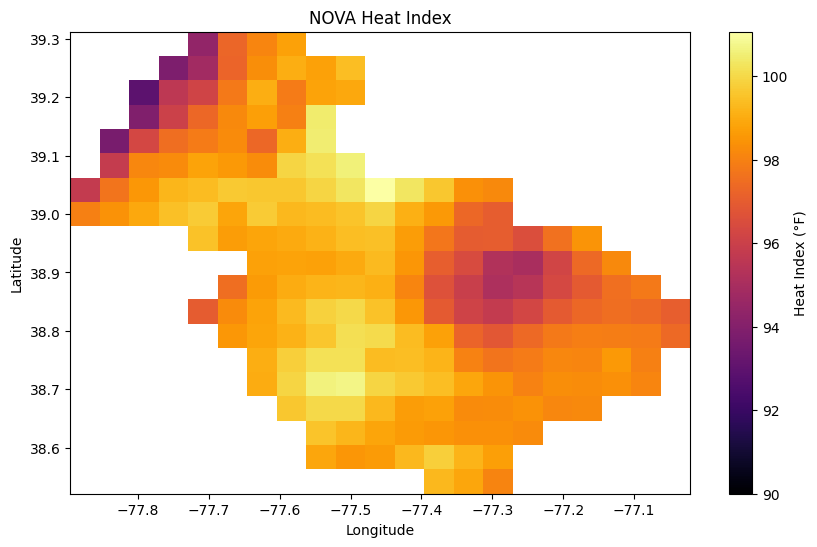

In [4]:
import os
import xarray as xr
import glob
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray

# SETUP
print("starting setup...")

temp_dir = "prism_daily_parts"
output_filename = "nova_heat_index_2023_season.nc"
nova_shape = gpd.read_file("nova_boundaries.geojson").to_crs("EPSG:4326")

tmax_files = sorted(glob.glob(os.path.join(temp_dir, "tmax_*.nc")))
print(f" found {len(tmax_files)} days to process.")

valid_days = []

# MERGE
print("pairing data...")

for tmax_path in tmax_files:
    # Get date (e.g., "20230501")
    filename = os.path.basename(tmax_path)
    date_str = filename.replace("tmax_", "").replace(".nc", "")
    tdmean_path = os.path.join(temp_dir, f"tdmean_{date_str}.nc")

    if os.path.exists(tdmean_path):
        try:
            with xr.open_dataset(tmax_path) as ds_t:
                var_t = [v for v in ds_t.data_vars if 'spatial_ref' not in v][0]
                da_tmax = ds_t[var_t]

            with xr.open_dataset(tdmean_path) as ds_td:
                var_td = [v for v in ds_td.data_vars if 'spatial_ref' not in v][0]
                da_td = ds_td[var_td]

            # merge
            ds = xr.Dataset({'tmax': da_tmax, 'tdmean': da_td})

            # set time
            dt = pd.to_datetime(date_str, format="%Y%m%d")
            ds = ds.expand_dims(time=[dt])

            valid_days.append(ds)

        except Exception as e:
            print(f"skipping {date_str}: {e}")

if not valid_days:
    raise ValueError("no valid days found.")

print(f"merging {len(valid_days)} days...")
ds_final = xr.concat(valid_days, dim='time')
ds_final = ds_final.sortby('time')
ds_final = ds_final.resample(time='D').interpolate('linear')  # interpolate gaps

# Heat Index Calculation
print(" Calculating Heat Index...")

# C -> F
ds_final['tmax_F'] = (ds_final['tmax'] * 1.8) + 32

# relative humidity calculation
num = np.exp((17.625 * ds_final['tdmean']) / (243.04 + ds_final['tdmean']))
den = np.exp((17.625 * ds_final['tmax']) / (243.04 + ds_final['tmax']))
ds_final['rh'] = 100 * (num / den)
ds_final['rh'] = ds_final['rh'].where(ds_final['rh'] <= 100, 100)

# heat index formula
def calculate_heat_index(T, RH):
    HI = 0.5 * (T + 61.0 + ((T - 68.0) * 1.2) + (RH * 0.094))
    HI_full = (-42.379 + 2.049*T + 10.14*RH - 0.224*T*RH -
               0.0068*T*T - 0.054*RH*RH + 0.0012*T*T*RH +
               0.00085*T*RH*RH - 0.00000199*T*T*RH*RH)

    adj1 = ((13 - RH) / 4) * np.sqrt((17 - np.abs(T - 95.)) / 17)
    HI_full = xr.where((RH < 13) & (T >= 80) & (T <= 112), HI_full - adj1, HI_full)
    adj2 = ((RH - 85) / 10) * ((87 - T) / 5)
    HI_full = xr.where((RH > 85) & (T >= 80) & (T <= 87), HI_full + adj2, HI_full)

    return xr.where(HI < 80, HI, HI_full)

ds_final['heat_index'] = calculate_heat_index(ds_final['tmax_F'], ds_final['rh'])

# fix dimensions & clip
print("Final Clip & Save...")

# Checking dimensions
x_name = 'x' if 'x' in ds_final.dims else 'lon'
y_name = 'y' if 'y' in ds_final.dims else 'lat'

# force rioxarray to recognize dimensions
ds_final.rio.set_spatial_dims(x_dim=x_name, y_dim=y_name, inplace=True)
ds_final.rio.write_crs("EPSG:4326", inplace=True)
ds_clipped = ds_final.rio.clip(nova_shape.geometry, nova_shape.crs, drop=True)
ds_clipped.to_netcdf(output_filename)
print(f"Saved: {output_filename}")

# visualization
hottest_idx = ds_clipped['heat_index'].mean(dim=[y_name, x_name]).argmax().item()
hottest_date = ds_clipped.isel(time=hottest_idx).time.values

plt.figure(figsize=(10, 6))
ds_clipped['heat_index'].isel(time=hottest_idx).plot(
    cmap='inferno',
    vmin=90,
    cbar_kwargs={'label': 'Heat Index (°F)'}
)

plt.title(f"NOVA Heat Index")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [9]:
# export normalized layer
print(" creating normalized heat stress layer...")

# aggregate
da_mean = ds_clipped['heat_index'].mean(dim='time')

df = da_mean.to_dataframe(name='heat_raw').reset_index()
df = df.dropna()

# normalize
min_val = df['heat_raw'].min()
max_val = df['heat_raw'].max()

df['heat_normalized'] = (df['heat_raw'] - min_val) / (max_val - min_val)

print(f"   Min Value (0.0): {min_val:.2f}°F")
print(f"   Max Value (1.0): {max_val:.2f}°F")

# create geodataframe
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df[x_name], df[y_name]),
    crs="EPSG:4326"
)

# relevant columns
gdf = gdf[['heat_normalized', 'geometry']]
gdf['heat_normalized'] = gdf['heat_normalized'].round(4) # Clean up decimals

# save
output_filename = "nova_heat_stress_normalized.geojson"
gdf.to_file(output_filename, driver='GeoJSON')

print(f"saved normalized layer to: {output_filename}")
print("ready for MCDA weighting (0 = Low Stress, 1 = High Stress)")

 creating normalized heat stress layer...
   Min Value (0.0): 76.82°F
   Max Value (1.0): 80.57°F
saved normalized layer to: nova_heat_stress_normalized.geojson
ready for MCDA weighting (0 = Low Stress, 1 = High Stress)
